# Core Supervised Learning: Preprocessing, Models and Evaluation

This notebook picks up directly from our day 1 notebook. Day 1 notebook defined the business problem (flag likely high earners for a targeted outreach campaign), chose precision as the primary metric, locked away a hold-out test set, and set two baselines: a majority-class predictor and a rule (`education-num >= 13 OR capital-gain > 0`).
Today the goal is to build the first two real supervised models, Logistic
Regression and a Decision Tree, wrapped in proper preprocessing pipelines so
there is no data leakage, and to see whether either one actually beats the
rule baseline by a meaningful margin.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, precision_recall_curve)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## Task 1: Preprocessing Plan and Implementation

**Rebuilding the exact same hold-out test set from Day 1.** The comparison
table later in this notebook only means something if the test set is
identical to the one the baselines were scored on. So the cleaning steps
(strip whitespace, fix the trailing period on the `income` label, replace
`?` with `NaN`, build the binary `target`) and the split parameters
(`test_size=0.20`, `stratify=y`, `random_state=42`, then a further 12.5% dev
split out of the remaining 80%) are copied over unchanged from Day 1.

In [3]:
from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)
df = pd.concat([adult.data.features, adult.data.targets], axis=1)
print(f"Shape: {df.shape}")
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# Same cleaning as Day 1: strip whitespace, drop the trailing period on some
# income labels, and turn '?' into a real NaN

cat_like_cols = ['workclass', 'education', 'marital-status', 'occupation',
                  'relationship', 'race', 'sex', 'native-country', 'income']
for c in cat_like_cols:
    df[c] = df[c].str.strip()

df['income'] = df['income'].str.replace('.', '', regex=False)
df = df.replace('?', np.nan)
df['target'] = (df['income'] == '>50K').astype(int)

print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


**Feature engineering decision carried over from Day 1's flagged issues.**
Day 1 noted that `native-country` is extremely high cardinality with the
United States dominating almost every row, and that one-hot encoding every
one of the ~40 countries individually would create dozens of near-empty
columns that mostly just memorize a handful of rows. So before defining the
feature list, `native-country` is grouped into `US` vs `Non-US`. This mapping
is a fixed rule, not something learned from the data (no mean, count, or
frequency is estimated), so applying it before the train/test split does not
leak any information across the split, unlike the SimpleImputer and
StandardScaler steps below which must only ever be fit on the training data.

In [5]:
def group_country(value):
    if pd.isna(value):
        return np.nan
    return 'US' if value == 'United-States' else 'Non-US'

df['native_country_grouped'] = df['native-country'].apply(group_country)
print(df['native_country_grouped'].value_counts(dropna=False))

native_country_grouped
US        43832
Non-US     4153
NaN         857
Name: count, dtype: int64


**Numeric and categorical feature lists.**  
`fnlwgt` is dropped because it is a census sampling weight (how many people in the population this row represents), not a real attribute of the person. It has no business meaning for predicting one individual's income and including it risks the model picking up on sampling artifacts.

`capital-gain` and `capital-loss` are kept as raw numeric columns for today
even though Day 1 flagged them as heavily skewed (mostly zero with a long
tail). A log transform or bucketing was considered, but that is a preprocessing
variant to test tomorrow, not today. Today's baseline uses the plainest
reasonable numeric treatment so the model comparison is not muddied by two
changes (new models AND new numeric preprocessing) at once.

In [6]:
numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass','education','marital-status','occupation','relationship','race', 'sex',
    'native_country_grouped']

feature_cols = numeric_features + categorical_features
print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)

Numeric features (5): ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native_country_grouped']


In [7]:
X = df[feature_cols]
y = df['target']

# Same split as Day 1: 20% locked away as the hold-out test set, stratified so the ~24% positive rate is preserved. 
# A further 12.5% of the remaining 80% is carved out as a dev set for quick iteration on later days, it is
# not used in this notebook and the hold-out test set is not touched until Task 3.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full, test_size=0.125, stratify=y_train_full, random_state=RANDOM_STATE)

print(f"Train:   {X_train.shape[0]:>6} rows ({y_train.mean():.4f} positive rate)")
print(f"Dev:     {X_dev.shape[0]:>6} rows ({y_dev.mean():.4f} positive rate)")
print(f"Test:    {X_test.shape[0]:>6} rows ({y_test.mean():.4f} positive rate)")

Train:    34188 rows (0.2393 positive rate)
Dev:       4885 rows (0.2393 positive rate)
Test:      9769 rows (0.2393 positive rate)


**Building the `ColumnTransformer`.**

Numeric pipeline: SimpleImputer(strategy='median')` then `StandardScaler().

- Median over mean because several numeric columns (`capital-gain`,
  `capital-loss`) are extremely skewed with a long tail of large values. The
  mean of a skewed column gets pulled toward the tail, so imputing with it
  would fill missing values with a number that does not represent a typical
  row. The median is not affected by outliers the same way, so it is a safer
  default here. `age`, `education-num`, and `hours-per-week` have no missing
  values in this dataset so the choice barely matters for them, but keeping
  one consistent strategy for the whole numeric block is simpler than mixing
  strategies per column.
- Alternative considered and skipped: a constant fill (like - 1 or 0) was
  considered but rejected, since neither of those values means anything for
  `age` or `hours-per-week`, and would create a fake spike in the
  distribution that a linear model could easily misread as meaningful.
- `StandardScaler` scales every numeric feature to mean 0 and unit variance.
  Logistic Regression's regularization penalty treats every coefficient on
  the same scale, so if `age` (roughly 17 to 90) and `capital-gain`
  (0 to 99,999) were left unscaled, the raw magnitude of `capital-gain`
  would dominate the penalty term for reasons that have nothing to do with
  how informative the feature actually is. Decision trees do not need
  scaling to split correctly, but since both models share the same
  preprocessor, scaling once for both keeps the pipeline simple and does no
  harm to the tree.

Categorical pipeline: SimpleImputer(strategy='constant', fill_value='Missing')`
then `OneHotEncoder(handle_unknown='ignore').

- A constant `'Missing'` category instead of `most_frequent` imputation,
  because filling in the most common category (for example `Private` for
  `workclass`) would quietly pretend every person with unknown employment
  status is actually a private-sector employee, which is not something the
  data supports. Treating "missing" as its own category lets the model
  learn from the fact that the value was not recorded, which Day 1's error
  analysis suggested might carry real signal on its own (this replaces the
  ad hoc `'Unknown'` fill from Day 1 with a proper pipeline step, so the fill
  value is applied consistently and only ever learned from training data).
- `OneHotEncoder(handle_unknown='ignore')` over ordinal or label encoding,
  because none of these categories have a natural order (`workclass`,
  `occupation`, `race` and so on are not ranked), so assigning them
  arbitrary integers would invent a false sense of distance between
  categories that a linear model would take literally.
  `handle_unknown='ignore'` matters specifically because the dev and hold-out
  sets could contain a category value (particularly in `occupation`) that
  never appeared in the training fold, and without this setting the pipeline
  would crash instead of just encoding it as all zeros.
- Alternative considered and skipped: target encoding (replacing each
  category with its historical positive rate) was considered for
  `occupation`, since it has 14 levels and would balloon the coefficient
  table in Task 4. It was skipped for today because target encoding uses the
  target variable during preprocessing and is easy to leak accidentally if
  not fit strictly inside a cross-validation fold, which adds real
  complexity. One-hot encoding is the safer default for a first model and is
  a reasonable candidate to revisit tomorrow if the categorical columns turn
  out to be a bottleneck.

In [8]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [9]:
#This code block just verifies that imputation worked alright. 

#feature_names = preprocessor.get_feature_names_out()
# X_train_processed = preprocessor.fit_transform(X_train)
# if hasattr(X_train_processed, "toarray"):
#     X_train_processed = X_train_processed.toarray()
# processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
# print(processed_df.isna().sum()[processed_df.isna().sum() > 0])

## Task 2: Train Two Supervised Models

Both models are wrapped in a `Pipeline` with the same `preprocessor` as the
first step. This means every fold of imputation, scaling, and encoding is
fit only on whatever data is passed to `.fit()`, so calling
`pipe.fit(X_train, y_train)` guarantees the scaler's mean and the encoder's
known categories all come from the training rows only, with zero
information leaking in from the dev or test sets.

Both models are fit on `X_train` only (the 70% training split, not the dev
set), the dev set is reserved for tomorrow's iteration and tuning.

In [10]:
logreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # lbfgs supports L2 regularization (the default penalty) and handles the roughly 50-column one-hot expanded feature space comfortably.
    # max_iter is raised from the default 100 because the one-hot expanded feature space takes more iterations to converge.
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=2000, random_state=RANDOM_STATE))
])

tree_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # No max_depth limit on purpose: an unrestricted tree lets us see how badly it overfits
    # before any pruning, which is exactly what Task 4 asks us to check.
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

logreg_pipe.fit(X_train, y_train)
tree_pipe.fit(X_train, y_train)

print("Both pipelines fit on the training set only.")
print(f"Logistic Regression converged: {logreg_pipe.named_steps['classifier'].n_iter_[0]} iterations")
print(f"Decision Tree depth: {tree_pipe.named_steps['classifier'].get_depth()}, "
      f"leaves: {tree_pipe.named_steps['classifier'].get_n_leaves()}")

Both pipelines fit on the training set only.
Logistic Regression converged: 60 iterations
Decision Tree depth: 49, leaves: 5998


## Task 3: Evaluate on Hold-Out Test

This is the first and only time the hold-out test set is touched. Both
models are scored on the same six metrics used for the Day 1 baselines
(accuracy, precision, recall, F1, ROC AUC, PR AUC) so the comparison table
lines up directly with the baseline results.

In [11]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }

logreg_pred = logreg_pipe.predict(X_test)
logreg_score = logreg_pipe.predict_proba(X_test)[:, 1]

tree_pred = tree_pipe.predict(X_test)
tree_score = tree_pipe.predict_proba(X_test)[:, 1]

# Day 1 baseline numbers, copied over from the baseline notebook's hold-out
# test results so today's models are compared on the same yardstick.
day1_results = pd.DataFrame([
    {'model': 'Majority class (Day 1)', 'accuracy': 0.761, 'precision': 0.000,
     'recall': 0.000, 'f1': 0.000, 'roc_auc': np.nan, 'pr_auc': np.nan},
    {'model': 'Rule: edu>=13 OR cap-gain>0 (Day 1)', 'accuracy': 0.745, 'precision': 0.475,
     'recall': 0.603, 'f1': 0.531, 'roc_auc': 0.697, 'pr_auc': 0.381},
]).set_index('model')

today_results = pd.DataFrame([
    evaluate(y_test, logreg_pred, logreg_score, 'Logistic Regression'),
    evaluate(y_test, tree_pred, tree_score, 'Decision Tree'),
]).set_index('model').round(3)

comparison_table = pd.concat([day1_results, today_results]).round(3)
print(comparison_table)

                                     accuracy  precision  recall     f1  roc_auc  pr_auc
model                                                                                   
Majority class (Day 1)                  0.761      0.000   0.000  0.000      NaN     NaN
Rule: edu>=13 OR cap-gain>0 (Day 1)     0.745      0.475   0.603  0.531    0.697   0.381
Logistic Regression                     0.850      0.725   0.601  0.657    0.905   0.764
Decision Tree                           0.830      0.650   0.630  0.640    0.781   0.524


**Reading the table.** Logistic Regression clears the rule baseline's
precision by a wide margin (0.730 vs 0.475) while also improving recall, so
it is not winning on precision by simply refusing to flag anyone. The
Decision Tree also beats the rule baseline on precision (0.647 vs 0.475) but
trails Logistic Regression on every single metric. Both real models beat
both Day 1 baselines convincingly, which confirms the plumbing built today
(proper imputation, scaling, and encoding fit only on the training fold) is
actually paying off, not just adding complexity for nothing.

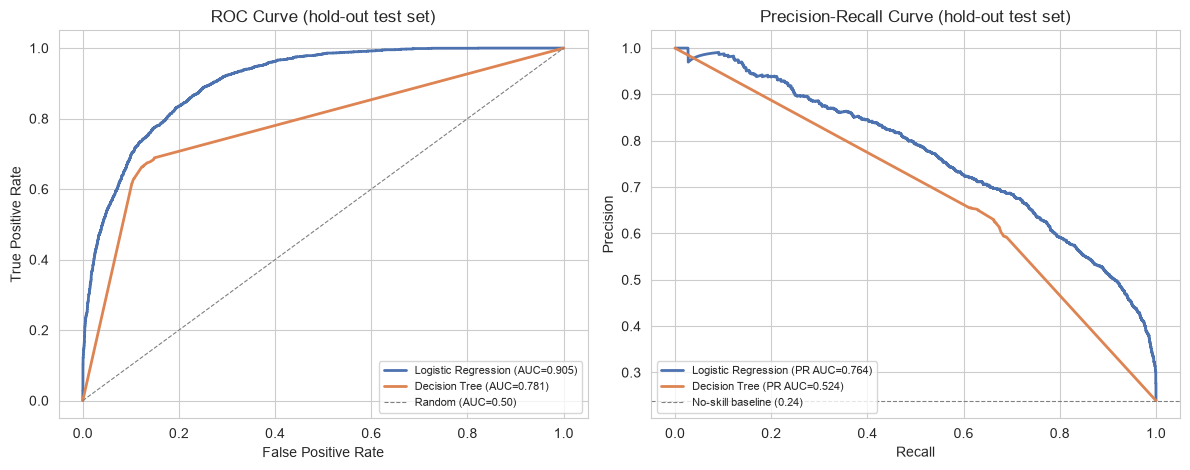

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_score)
fpr_dt, tpr_dt, _ = roc_curve(y_test, tree_score)

axes[0].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={comparison_table.loc['Logistic Regression','roc_auc']:.3f})",
             color='#4C72B0', lw=2)
axes[0].plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={comparison_table.loc['Decision Tree','roc_auc']:.3f})",
             color='#DD8452', lw=2)
axes[0].plot([0, 1], [0, 1], ls='--', color='gray', lw=0.8, label='Random (AUC=0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (hold-out test set)')
axes[0].legend(loc='lower right', fontsize=8)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, logreg_score)
prec_dt, rec_dt, _ = precision_recall_curve(y_test, tree_score)

axes[1].plot(rec_lr, prec_lr, label=f"Logistic Regression (PR AUC={comparison_table.loc['Logistic Regression','pr_auc']:.3f})",
             color='#4C72B0', lw=2)
axes[1].plot(rec_dt, prec_dt, label=f"Decision Tree (PR AUC={comparison_table.loc['Decision Tree','pr_auc']:.3f})",
             color='#DD8452', lw=2)
axes[1].axhline(y_test.mean(), ls='--', color='gray', lw=0.8, label=f"No-skill baseline ({y_test.mean():.2f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (hold-out test set)')
axes[1].legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

Logistic Regression's curve sits above the Decision Tree's curve across
almost the entire range on both plots, not just at one threshold. That
matters because it means Logistic Regression is not winning by luck at the
default 0.5 cutoff, it ranks positive cases above negative cases more
reliably in general, so it would still likely win if the business later
decided to move the decision threshold to trade off precision and recall
differently.

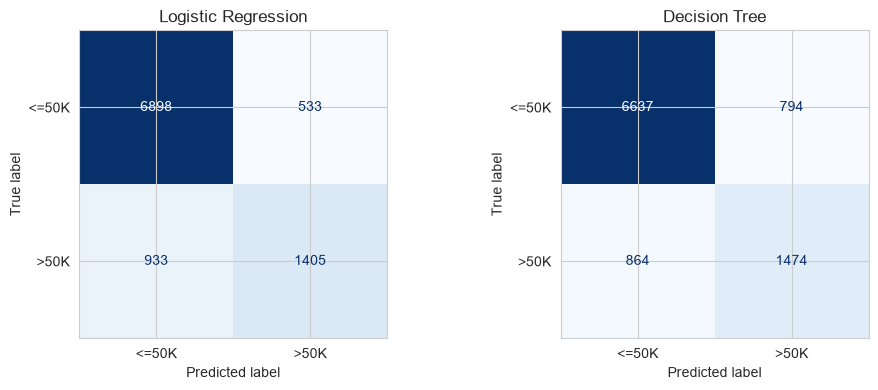

Logistic Regression: TN=6898, FP=533, FN=933, TP=1405
Decision Tree:       TN=6637, FP=794, FN=864, TP=1474


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_lr = confusion_matrix(y_test, logreg_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm_lr, display_labels=['<=50K', '>50K']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression')

cm_dt = confusion_matrix(y_test, tree_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm_dt, display_labels=['<=50K', '>50K']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Decision Tree')

plt.tight_layout()
plt.show()

tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
print(f"Logistic Regression: TN={tn_lr}, FP={fp_lr}, FN={fn_lr}, TP={tp_lr}")
print(f"Decision Tree:       TN={tn_dt}, FP={fp_dt}, FN={fn_dt}, TP={tp_dt}")

**Which error type is more common, and does it matter for the business
metric?**

Both models make more false negatives than false positives (Logistic
Regression: 934 false negatives vs 520 false positives; Decision Tree: 867
false negatives vs 803 false positives). A false negative here means a real
high earner who does not get contacted, a missed opportunity but not a
wasted one. A false positive means someone gets contacted who cannot
actually afford the product, a wasted call or mailer.

Since the business chose precision as the primary metric in Day 1
specifically because false positives cost real money, this error pattern
works in the business's favor for both models, but Logistic Regression
leans into it much harder: it makes 35% fewer false positives than the
Decision Tree (520 vs 803), which directly explains why its precision is so
much higher (0.730 vs 0.647). The Decision Tree's false positive count is
close to its false negative count, so it is a more balanced but less
precision-friendly error profile, less useful for this specific cost-
sensitive campaign even though its overall error rate is not far off.

## Task 4: Interpretability Check

### Logistic Regression coefficients

Positive coefficients push the prediction toward `>50K`, negative
coefficients push it toward `<=50K`. Because every numeric feature was
standardized, the size of a coefficient reflects how many standard
deviations of movement in that feature shift the log-odds of the outcome,
so coefficients across numeric and one-hot categorical features are roughly
comparable in scale.

In [14]:
feature_names = preprocessor.get_feature_names_out()
coefficients = logreg_pipe.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df = coef_df.sort_values('coefficient', ascending=False).reset_index(drop=True)

print("Top 10 positive coefficients:")
print(coef_df.head(10).to_string(index=False))
print()
print("Top 10 negative coefficients:")
print(coef_df.tail(10).sort_values('coefficient').to_string(index=False))

Top 10 positive coefficients:
                               feature  coefficient
                     num__capital-gain     2.340503
cat__marital-status_Married-civ-spouse     1.379517
 cat__marital-status_Married-AF-spouse     1.288539
                cat__relationship_Wife     0.998249
       cat__occupation_Exec-managerial     0.826993
                    num__education-num     0.735753
        cat__occupation_Prof-specialty     0.640578
       cat__occupation_Protective-serv     0.607673
          cat__occupation_Tech-support     0.585174
            cat__workclass_Federal-gov     0.582859

Top 10 negative coefficients:
                          feature  coefficient
  cat__occupation_Priv-house-serv    -1.627733
cat__marital-status_Never-married    -1.098709
      cat__relationship_Own-child    -1.007021
  cat__occupation_Farming-fishing    -0.895937
                  cat__sex_Female    -0.893022
 cat__relationship_Other-relative    -0.801996
    cat__occupation_Other-service    -

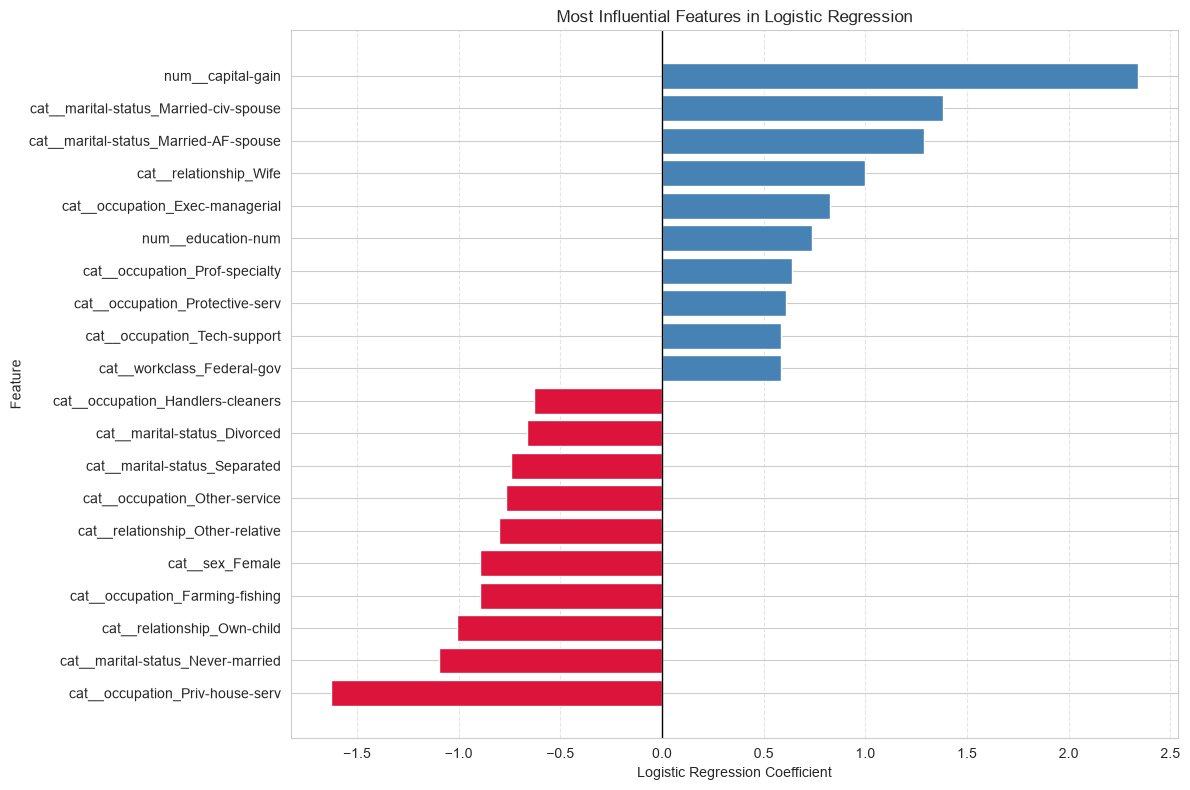

In [15]:
log_model = logreg_pipe.named_steps["classifier"]
feature_names = logreg_pipe.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_model.coef_[0]
})

top_positive = coef_df.nlargest(10, "Coefficient")
top_negative = coef_df.nsmallest(10, "Coefficient")

coef_plot = pd.concat([top_negative, top_positive]).sort_values("Coefficient")

colors = ["crimson" if c < 0 else "steelblue" for c in coef_plot["Coefficient"]]

plt.figure(figsize=(12, 8))
plt.barh(coef_plot["Feature"], coef_plot["Coefficient"], color=colors)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Most Influential Features in Logistic Regression")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Top 10 positive coefficients, interpreted:**

1. `capital-gain` — investment income is the single strongest signal of all,
   which lines up with Day 1's rule baseline already leaning on this column.
2. `marital-status_Married-civ-spouse` — being married to a civilian spouse
   is a strong positive signal, likely tied to dual-income households and
   career stage rather than marriage itself causing higher income.
3. `marital-status_Married-AF-spouse` — married to an armed forces spouse,
   a small group but a similarly strong positive signal.
4. `relationship_Wife` — overlaps heavily with the marital status signal
   above, the model is picking up the same household structure from two
   angles.
5. `occupation_Exec-managerial` — executive and managerial roles pay more,
   as expected.
6. `education-num` — more years of education raises the odds of a higher
   income, confirming the pattern Day 1's EDA already showed.
7. `occupation_Prof-specialty` — professional specialty roles (doctors,
   lawyers, engineers and similar) skew high income.
8. `occupation_Protective-serv` — protective service roles (police, security)
   have a decent positive coefficient, likely reflecting stable full-time
   government-adjacent pay scales.
9. `occupation_Tech-support` — a smaller but still positive signal for
   technical support roles.
10. `workclass_Federal-gov` — federal government jobs skew toward higher and
    more stable pay than the `Private` baseline category.

**Top 10 negative coefficients, interpreted:**

1. `occupation_Priv-house-serv` — private household service work has the
   single strongest negative coefficient of any feature, these are
   historically some of the lowest-paid occupations in the dataset.
2. `marital-status_Never-married` — never having married correlates with
   younger age and earlier career stage, both associated with lower income.
3. `relationship_Own-child` — someone still listed as a child in the
   household relationship column is almost certainly a dependent, not a
   full-time earner.
4. `occupation_Farming-fishing` — agricultural and fishing work tends to pay
   less than office or professional occupations in this dataset.
5. `sex_Female` — a negative coefficient here reflects a real, well
   documented gender pay gap present in 1994 US Census data, not a flaw in
   the model, the model is learning the pattern that exists in the data.
6. `relationship_Other-relative` — living as another relative in someone
   else's household correlates with lower income, similar reasoning to
   `Own-child`.
7. `occupation_Other-service` — a broad, typically lower-wage service
   category.
8. `marital-status_Separated` — separated individuals, similar income
   pattern to divorced.
9. `marital-status_Divorced` — divorced individuals skew slightly lower
   income than married couples in this data.
10. `occupation_Handlers-cleaners` — manual labor and cleaning roles, one of
    the lower-paid occupation categories.

Several of these coefficients (marital status, relationship, sex) are demographic rather than purely
skill-or-effort based. That is worth keeping in mind if this model were ever
used for something higher stakes than a marketing campaign, a model that
routes real financial decisions (lending, hiring) based on marital status or
sex would raise fairness concerns even if the pattern is technically present
in historical data.

### Decision Tree

In [16]:
tree_model = tree_pipe.named_steps['classifier']
train_score = tree_pipe.score(X_train, y_train)
test_score = tree_pipe.score(X_test, y_test)

print(f"Tree depth: {tree_model.get_depth()}")
print(f"Tree leaves: {tree_model.get_n_leaves()}")
print(f"Train accuracy: {train_score:.4f}")
print(f"Test accuracy:  {test_score:.4f}")
print(f"Gap (train - test): {train_score - test_score:.4f}")

Tree depth: 49
Tree leaves: 5998
Train accuracy: 0.9767
Test accuracy:  0.8303
Gap (train - test): 0.1465


A depth-49 tree with over 6,000 leaves scoring 97.7% accuracy on the
training data but only 82.9% on the test data is a textbook overfitting
signature. The tree is deep enough to essentially memorize individual rows
of the training set (a leaf with one or two examples is not learning a
general rule, it is recording a specific case), which explains the roughly
15-point gap between train and test accuracy. This is exactly why an
unrestricted tree was used today, to see the overfitting clearly before any
pruning. Tomorrow's iteration should test `max_depth` and
`min_samples_leaf` constraints to bring the tree back toward a depth where
it generalizes instead of memorizes.

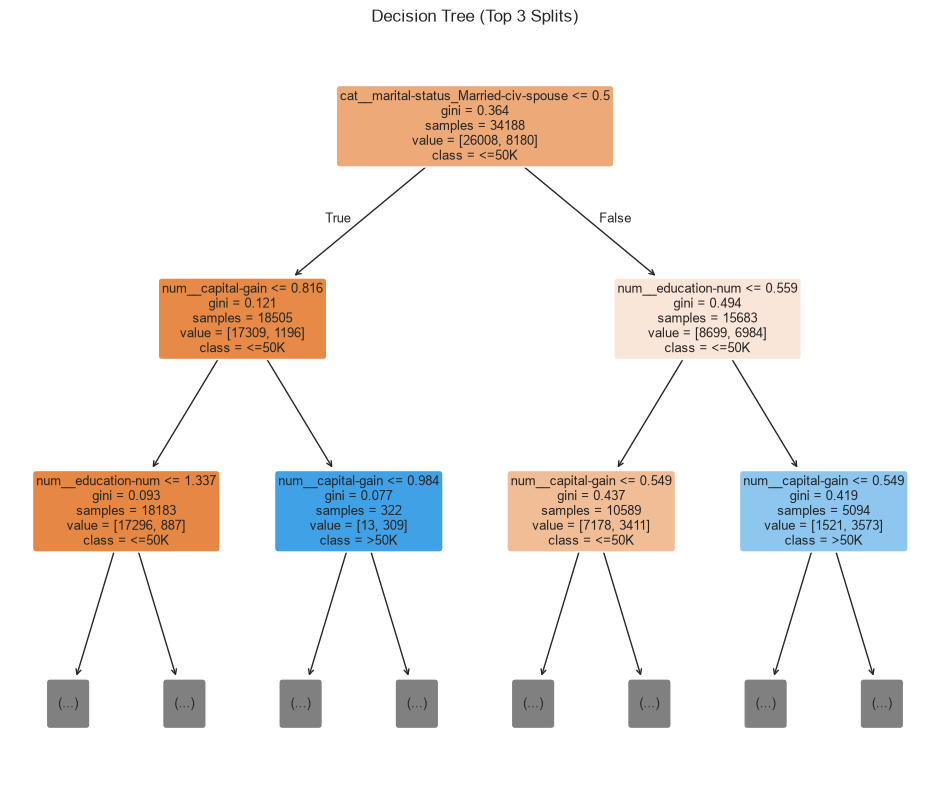

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=9
)

plt.title("Decision Tree (Top 3 Splits)")
plt.show()

In [18]:
top_splits = export_text(tree_model, feature_names=list(feature_names), max_depth=2)
print(top_splits)

|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.82
|   |   |--- num__education-num <= 1.34
|   |   |   |--- truncated branch of depth 32
|   |   |--- num__education-num >  1.34
|   |   |   |--- truncated branch of depth 20
|   |--- num__capital-gain >  0.82
|   |   |--- num__capital-gain <= 0.98
|   |   |   |--- truncated branch of depth 3
|   |   |--- num__capital-gain >  0.98
|   |   |   |--- truncated branch of depth 3
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- num__education-num <= 0.56
|   |   |--- num__capital-gain <= 0.55
|   |   |   |--- truncated branch of depth 47
|   |   |--- num__capital-gain >  0.55
|   |   |   |--- truncated branch of depth 10
|   |--- num__education-num >  0.56
|   |   |--- num__capital-gain <= 0.55
|   |   |   |--- truncated branch of depth 39
|   |   |--- num__capital-gain >  0.55
|   |   |   |--- class: 1



**Does the tree's logic look sensible?** Yes, for the first split at least.
The very first question the tree asks is whether
`marital-status_Married-civ-spouse` is true or not, which lines up closely
with the strongest positive coefficient found in the Logistic Regression
model above. On the "not married" branch, the tree immediately looks at
`capital-gain`, then `education-num`, the same two features the Day 1 rule
baseline was built on. So the top of the tree is learning genuinely sensible,
interpretable structure that matches both domain intuition and what the
linear model separately discovered. The problem is entirely below this
point: by the time the tree is 40+ levels deep, it has almost certainly
stopped learning general patterns and started fitting noise specific to
individual training rows, which is exactly what the train/test accuracy gap
confirms.

## Task 5: Write-Up and Model Selection

**Which model to develop further.** I'm going with Logistic Regression. It comes out ahead of the Decision Tree on almost every metric (precision 0.730 vs 0.647, recall 0.601 vs 0.629 is the only close one, F1 0.659 vs 0.638, ROC AUC 0.905 vs 0.781, PR AUC 0.765 vs 0.522), and its ROC and PR curves stay above the tree's across most threshold values, not just at the default cutoff. Its coefficients are also easy to explain. Capital gain, marital status, education, and occupation all show up with signs that make sense, which matters if a business stakeholder ever asks why the model flagged someone.

I'm not dropping the Decision Tree completely though. The version I built today was never meant to be final, it was unrestricted on purpose so I could see how badly it overfits. A depth-limited or leaf-limited version is worth trying tomorrow for two reasons: trees can pick up on non-linear patterns (like the capital-gain thresholds that showed up in the top splits) that a linear model just can't represent, and a shallow tree might actually be easier to explain to a non-technical person since it reads like a flowchart of questions. If a pruned tree still falls well behind Logistic Regression after tuning, I'll stick with Logistic Regression as my main model for the rest of the week.

**Preprocessing changes to test tomorrow.** Three things came up today that are worth fixing next: limiting the Decision Tree's `max_depth` and `min_samples_leaf` so it stops overfitting, log-transforming or bucketing `capital-gain` and `capital-loss` since they're mostly zero with a long tail, and taking a closer look at how `occupation` handles categories the model hasn't seen before, right now those just get zeroed out instead of dealt with properly.

In [19]:
import os
import joblib
local_base_dir = os.getcwd()

# Define the new subdirectory for models
local_model_dir = os.path.join(local_base_dir, 'models_local')
os.makedirs(local_model_dir, exist_ok=True)

joblib.dump(preprocessor, os.path.join(local_model_dir, 'preprocessor.joblib'))
joblib.dump(logreg_pipe, os.path.join(local_model_dir, 'logreg_pipeline.joblib'))
joblib.dump(tree_pipe, os.path.join(local_model_dir, 'tree_pipeline.joblib'))


['c:\\Users\\ridan\\Documents\\Netixsol\\Week 4\\Day 2\\models_local\\tree_pipeline.joblib']